# Signal Validation & Statistical Rigour

**Research Question:** Do our alpha signals hold up under proper statistical correction — and can we recover Bollinger's edge by matching rebalance frequency to signal horizon?

## Context

Notebook 02 identified two surviving factors — **Momentum 12-1** and **Bollinger** — but flagged critical methodology flaws:

1. **Overlapping forward returns inflated t-statistics by ~4.6x.** The reported t-stats assumed independent daily observations, but 21d forward returns share 20/21 days between consecutive dates.
2. **Bollinger's IC-to-P&L gap:** strongest IC yet worst backtest (Sharpe = -0.93). Daily rebalancing generated turnover costs that destroyed the edge.
3. **Regime dependence:** Momentum's IC was far stronger post-2024 than pre-2024.

This notebook applies the validation module built in Phase 2.5 — on a larger 50-stock universe — to answer: **after honest corrections, which signals are real, and can implementation close the gap?**

## Dropped Factors

- **XS Momentum:** redundant (identical IC to raw Momentum, weaker backtest due to rank compression)
- **RSI:** insignificant IC at every horizon, high correlation with Bollinger (0.88), no robustness

## 0. Setup

In [ ]:
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from qre.data.historical import HistoricalDataStore
from qre.alpha.factors import BollingerZScore, Momentum
from qre.analytics.ic import compute_ic, ic_decay, ic_summary, newey_west_t_stat, non_overlapping_ic, block_bootstrap_ci
from qre.analytics.metrics import sharpe_ratio
from qre.analytics.validation import (
    signal_autocorrelation,
    signal_turnover,
    cross_sectional_dispersion,
    signal_return_lead_lag,
)
from qre.backtest.vectorized import VectorizedBacktester

sns.set_theme(style="whitegrid")

COLORS = {
    "Momentum 12-1": "#6b1f2b",
    "Bollinger": "#2b4b6b",
}

plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

## 1. Data & Signal Generation

50 liquid US large-caps spanning all 11 GICS sectors. The larger cross-section increases statistical power (single-day IC SE ~0.14 vs ~0.28 with fewer stocks) and reduces sensitivity to any single name. Still survivorship-biased (current names selected with hindsight).

In [2]:
store = HistoricalDataStore(adjustment="adjusted")

UNIVERSE = [
    # Technology
    "AAPL", "MSFT", "NVDA", "GOOGL", "META", "AVGO", "ADBE", "CRM",
    # Financials
    "JPM", "GS", "BAC", "WFC", "MS", "BLK",
    # Healthcare
    "JNJ", "UNH", "PFE", "ABT", "LLY", "TMO",
    # Consumer Discretionary
    "AMZN", "TSLA", "HD", "NKE", "MCD",
    # Consumer Staples
    "PG", "WMT", "KO", "PEP", "COST",
    # Energy
    "XOM", "CVX", "COP",
    # Industrials
    "CAT", "HON", "UPS", "RTX",
    # Communication
    "V", "MA", "NFLX", "DIS",
    # Utilities
    "NEE", "DUK",
    # Real Estate
    "AMT", "PLD",
    # Materials
    "LIN", "SHW",
]

START = datetime(2020, 1, 1)
END = datetime(2026, 5, 16)

# Fetch any tickers not yet cached
existing = set(store.list_tickers("1d"))
new_tickers = [t for t in UNIVERSE if t not in existing]
if new_tickers:
    print(f"Fetching {len(new_tickers)} new tickers: {new_tickers}")
    for ticker in new_tickers:
        _ = store.fetch_and_store(ticker, "1d", START, END)
    print("Done.")
else:
    print("All tickers already cached.")

# Load data and compute signals
panel = store.load_panel(UNIVERSE, "1d")
closes = panel["close"]

signals = {
    "Momentum 12-1": Momentum(window=252, skip=21).compute(closes),
    "Bollinger": BollingerZScore(window=20).compute(closes),
}

print(f"\nUniverse: {closes.shape[1]} tickers")
print(f"Period: {closes.index.min().date()} to {closes.index.max().date()}")
print(f"Shape: {closes.shape[0]} days x {closes.shape[1]} tickers")
print(f"Missing: {closes.isna().sum().sum()} NaNs\n")

for name, sig in signals.items():
    first = sig.dropna(how="all").index[0].date()
    n_vals = sig.notna().sum().sum()
    print(f"{name}: first signal {first}, {n_vals:,} values")

Fetching 33 new tickers: ['AVGO', 'ADBE', 'CRM', 'BAC', 'WFC', 'MS', 'BLK', 'PFE', 'ABT', 'LLY', 'TMO', 'TSLA', 'HD', 'NKE', 'MCD', 'KO', 'PEP', 'COST', 'CVX', 'COP', 'CAT', 'HON', 'UPS', 'RTX', 'MA', 'NFLX', 'DIS', 'NEE', 'DUK', 'AMT', 'PLD', 'LIN', 'SHW']
Done.

Universe: 47 tickers
Period: 2020-01-02 to 2026-05-15
Shape: 1601 days x 47 tickers
Missing: 0 NaNs

Momentum 12-1: first signal 2020-12-31, 63,403 values
Bollinger: first signal 2020-01-30, 74,354 values


## 2. Signal Diagnostics

Before any IC analysis, we characterize the signals themselves. Four questions:
- **Autocorrelation:** How sticky is the signal day-to-day? (quasi-static = daily rebalancing is churn)
- **Turnover:** How much do implied weights change daily? (low = rebalance less often)
- **Dispersion:** Does the signal differentiate stocks? (near-zero = no positions after neutralization)
- **Lead-lag:** Is the signal predictive or reactive? (negative-offset correlation = echoing past returns)

### 2a. Signal Autocorrelation

Momentum 12-1 lag-1 autocorrelation: 0.9903
Bollinger lag-1 autocorrelation: 0.8677


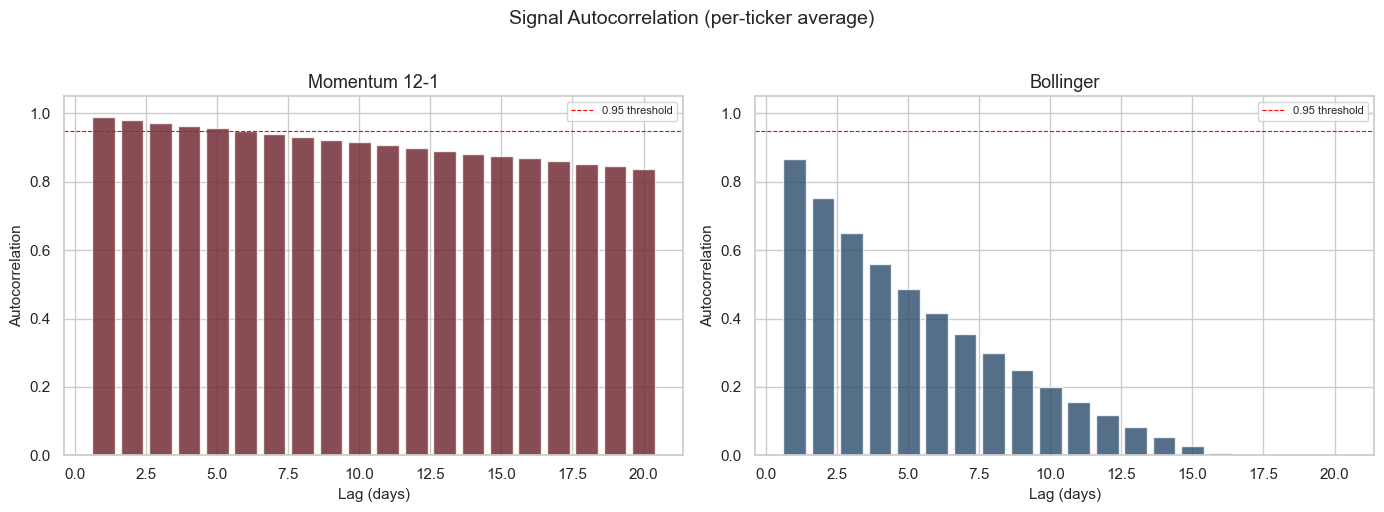

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, sig) in zip(axes, signals.items()):
    ac = signal_autocorrelation(sig, max_lag=20)
    ax.bar(ac["lag"], ac["autocorr"], color=COLORS[name], alpha=0.8)
    ax.axhline(0.95, color="red", linestyle="--", linewidth=0.8, label="0.95 threshold")
    ax.set_xlabel("Lag (days)")
    ax.set_ylabel("Autocorrelation")
    ax.set_title(f"{name}")
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)

    # Print lag-1 value
    lag1 = ac.loc[0, "autocorr"]
    print(f"{name} lag-1 autocorrelation: {lag1:.4f}")

plt.suptitle("Signal Autocorrelation (per-ticker average)", fontsize=14, y=1.02)
plt.tight_layout()

**Observations — Autocorrelation:**

- **Momentum (lag-1 = 0.990):** Extremely persistent — well above the 0.95 quasi-static threshold through ~lag 6. This makes sense: a 252-day lookback window shares 251/252 days between consecutive dates. Daily rebalancing would generate turnover for near-zero position change. This signal *demands* infrequent rebalancing.
- **Bollinger (lag-1 = 0.868):** Decays much faster — drops below 0.50 by lag 5 and approaches zero by lag 15. A 20-day window means the signal can flip in a few days as prices cross the bands. This signal *can* rebalance frequently, but as later sections show, there is no predictive power to exploit at any frequency.
- **Implication:** Momentum should rebalance on the order of weeks to reduce cost drag. For Bollinger, the autocorrelation structure is moot — frequency and smoothing only control how much you pay in transaction costs, not how much alpha you capture, because there is no detectable alpha.

### 2b. Signal Turnover & Dispersion

Momentum 12-1 mean turnover: 0.0940
Momentum 12-1 mean dispersion: 0.3273
Bollinger mean turnover: 0.4369
Bollinger mean dispersion: 1.0955


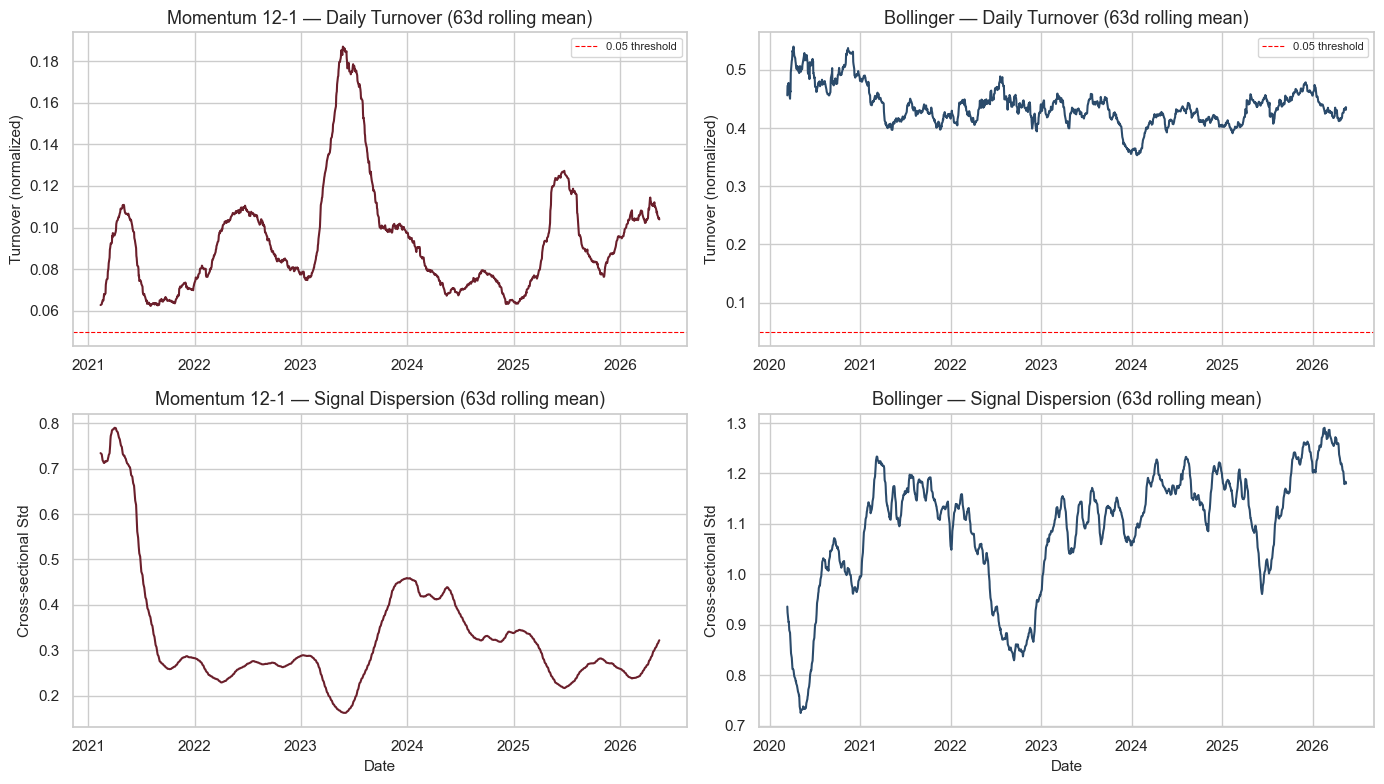

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for col, (name, sig) in enumerate(signals.items()):
    # Turnover
    ax = axes[0, col]
    to = signal_turnover(sig)
    to_rolling = to.rolling(63, min_periods=30).mean()
    ax.plot(to_rolling.index, to_rolling.values, color=COLORS[name])
    ax.axhline(0.05, color="red", linestyle="--", linewidth=0.8, label="0.05 threshold")
    ax.set_ylabel("Turnover (normalized)")
    ax.set_title(f"{name} — Daily Turnover (63d rolling mean)")
    ax.legend(fontsize=8)
    print(f"{name} mean turnover: {to.iloc[1:].mean():.4f}")

    # Dispersion
    ax = axes[1, col]
    disp = cross_sectional_dispersion(sig)
    disp_rolling = disp.rolling(63, min_periods=30).mean()
    ax.plot(disp_rolling.index, disp_rolling.values, color=COLORS[name])
    ax.set_ylabel("Cross-sectional Std")
    ax.set_title(f"{name} — Signal Dispersion (63d rolling mean)")
    ax.set_xlabel("Date")
    print(f"{name} mean dispersion: {disp.mean():.4f}")

plt.tight_layout()

**Observations — Turnover & Dispersion:**

- **Turnover:** Momentum's mean daily turnover (0.094) is 4.6x lower than Bollinger's (0.437). Momentum barely changes day-to-day (consistent with 0.99 autocorrelation), while Bollinger reshuffles nearly half the portfolio daily. This confirms NB02's finding: Bollinger's cost drag at 10 bps is devastating under daily rebalancing (~110 bps/day round-trip equivalent).
- **Momentum turnover spike (~0.18 in mid-2023):** Likely driven by a regime shift — several names may have crossed from negative to positive 12-month returns as the 2022 drawdown rolled out of the lookback window.
- **Dispersion:** Bollinger's cross-sectional dispersion (1.10) is 3.3x higher than Momentum's (0.33). Higher dispersion means stronger differentiation between stocks — good for generating positions after dollar-neutral normalization. Momentum's lower dispersion means positions are more tightly clustered, reducing effective bet size.
- **Momentum dispersion spikes (early 2021 ~0.8, mid-2023 ~0.45):** Correspond to periods where the cross-section of 12-month returns was unusually dispersed (post-COVID recovery, post-2022 bear market recovery).

### 2c. Lead-Lag Profile

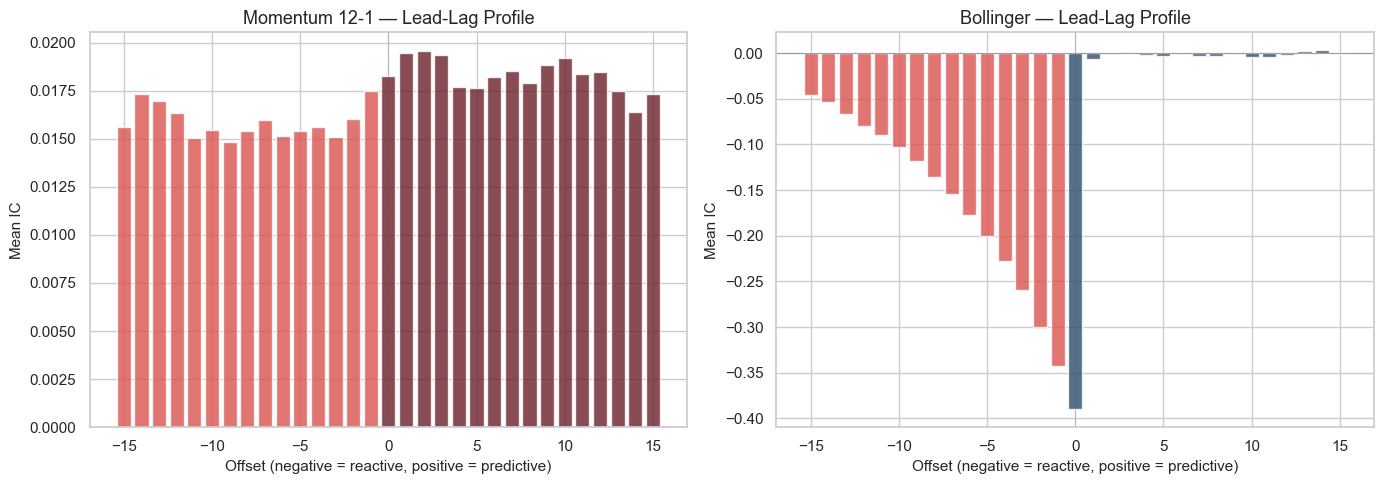

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, sig) in zip(axes, signals.items()):
    ll = signal_return_lead_lag(sig, closes, max_lead=15, max_lag=15)
    colors = ["#d9534f" if k < 0 else COLORS[name] for k in ll.index]
    ax.bar(ll.index, ll.values, color=colors, alpha=0.8)
    ax.axhline(0, color="grey", linewidth=0.5)
    ax.axvline(0, color="grey", linewidth=0.5, linestyle=":")
    ax.set_xlabel("Offset (negative = reactive, positive = predictive)")
    ax.set_ylabel("Mean IC")
    ax.set_title(f"{name} — Lead-Lag Profile")

plt.tight_layout()

**Observations — Lead-Lag Profile:**

- **Momentum:** All bars are positive and nearly symmetric across reactive (negative offsets) and predictive (positive offsets) sides, hovering around IC = 0.015-0.020. This is the signature of a *persistent* factor — momentum stocks tend to keep outperforming regardless of the measurement window. The lack of asymmetry means the signal is neither purely predictive nor purely reactive; it captures a slow-moving characteristic.
- **Bollinger:** Strong negative IC on the reactive side (offsets -15 to 0), peaking at offset 0 with IC ~ -0.40. The predictive side (offsets +1 to +15) is near zero. This is textbook *mean-reversion mechanics*: by construction, Bollinger z-scores are high when price is above the band (after a run-up), so the signal is mechanically anti-correlated with recent returns. The near-zero predictive side confirms that **Bollinger has no detectable forward-looking edge at any short-term horizon.**
- **Key insight:** The lead-lag profile is a useful diagnostic for separating mechanical correlation from genuine prediction. Bollinger's reactive side is entirely construction artefact — a z-score computed from recent prices will obviously correlate with those same recent returns. The predictive side is what matters, and it's flat.

## 3. Corrected IC Analysis

Standard t-statistics assume independent daily IC observations. With overlapping forward returns (e.g., 21d horizon shares 20/21 days between consecutive dates), this overstates significance by ~√h. We apply three corrections:

1. **Newey-West HAC t-statistic** — adjusts standard errors for autocorrelation (bandwidth = horizon - 1)
2. **Non-overlapping IC** — samples every h-th day for genuinely independent observations
3. **Block bootstrap 95% CI** — preserves serial dependence structure to give honest confidence intervals

In [6]:
HORIZONS = [1, 5, 10, 21]

rows = []
for name, sig in signals.items():
    for h in HORIZONS:
        fwd = closes.pct_change(h).shift(-h)
        ic_series = compute_ic(sig, fwd)

        stats = ic_summary(ic_series, sig, fwd, horizon=h, n_bootstrap=10_000, bootstrap_seed=42)

        rows.append({
            "Factor": name,
            "Horizon": f"{h}d",
            "Mean IC": stats["mean"],
            "ICIR": stats["icir"],
            "t (naive)": stats["t_stat"],
            "t (NW)": stats["t_stat_nw"],
            "Inflation": abs(stats["t_stat"] / stats["t_stat_nw"]) if stats["t_stat_nw"] != 0 else float("nan"),
            "95% CI": f"[{stats['ci_lower']:+.4f}, {stats['ci_upper']:+.4f}]",
            "N dates": stats["n_dates"],
        })

corrected_table = pd.DataFrame(rows)

display_cols = ["Factor", "Horizon", "Mean IC", "ICIR", "t (naive)", "t (NW)", "Inflation", "95% CI"]
(
    corrected_table[display_cols]
    .style
    .format({
        "Mean IC": "{:.4f}", "ICIR": "{:.3f}",
        "t (naive)": "{:.2f}", "t (NW)": "{:.2f}",
        "Inflation": "{:.1f}x",
    })
    .set_caption("IC Summary — Naive vs Newey-West Corrected")
)

,Factor,Horizon,Mean IC,ICIR,t (naive),t (NW),Inflation,95% CI
0,Momentum 12-1,1d,0.0195,0.064,2.35,2.35,1.0x,"[+0.0030, +0.0354]"
1,Momentum 12-1,5d,0.0226,0.077,2.82,1.57,1.8x,"[-0.0054, +0.0508]"
2,Momentum 12-1,10d,0.0237,0.085,3.12,1.29,2.4x,"[-0.0122, +0.0593]"
3,Momentum 12-1,21d,0.0307,0.122,4.43,1.28,3.5x,"[-0.0174, +0.0771]"
4,Bollinger,1d,-0.0061,-0.023,-0.91,-0.91,1.0x,"[-0.0194, +0.0068]"
5,Bollinger,5d,-0.0052,-0.021,-0.84,-0.50,1.7x,"[-0.0259, +0.0148]"
6,Bollinger,10d,0.0007,0.003,0.12,0.06,2.1x,"[-0.0240, +0.0264]"
7,Bollinger,21d,0.0094,0.041,1.61,0.63,2.5x,"[-0.0180, +0.0399]"


**Observations — Corrected IC:**

- **Inflation scales with horizon as expected.** At 1d there's no overlap, so naive = NW (1.0x). At 21d the inflation is 3.5x for Momentum — close to the theoretical sqrt(21) ~ 4.6x. The gap from theory comes from IC series not being perfectly autocorrelated.
- **Momentum's naive t = 4.43 at 21d looked "highly significant" — after NW correction it's 1.28**, below the 95% threshold. The bootstrap CI [-0.017, +0.077] straddles zero. The signal that looked like a slam-dunk in NB02 is marginal after honest correction.
- **Bollinger is insignificant at every horizon after correction.** Best case (21d): t(NW) = 0.63, CI = [-0.018, +0.040]. The daily IC is slightly negative (-0.006), confirming the lead-lag finding that Bollinger has no daily-frequency predictive power.
- **Momentum's mean IC increases with horizon** (0.020 at 1d to 0.031 at 21d), consistent with a slow-moving signal. But statistical confidence *decreases* because the NW correction grows harsher as overlap increases.
- **Reality check:** These are crude, well-known factors on a survivorship-biased universe. Marginal significance is the honest outcome — the NB02 results were inflated by overlapping returns masquerading as independent observations.

## 4. Non-Overlapping IC

An alternative to Newey-West: sample every h-th day so return windows are completely disjoint. Fewer observations (~65 at the 21d horizon vs ~1,300 daily), but each is genuinely independent.

In [7]:
no_rows = []
for name, sig in signals.items():
    for h in HORIZONS:
        fwd = closes.pct_change(h).shift(-h)

        # Daily (overlapping) IC
        ic_daily = compute_ic(sig, fwd)
        daily_stats = ic_summary(ic_daily)

        # Non-overlapping IC
        ic_no = non_overlapping_ic(sig, fwd, horizon=h)
        no_stats = ic_summary(ic_no)

        no_rows.append({
            "Factor": name,
            "Horizon": f"{h}d",
            "Daily Mean IC": daily_stats["mean"],
            "Daily N": daily_stats["n_dates"],
            "Daily t": daily_stats["t_stat"],
            "Non-Overlap Mean IC": no_stats["mean"],
            "Non-Overlap N": no_stats["n_dates"],
            "Non-Overlap t": no_stats["t_stat"],
        })

no_table = pd.DataFrame(no_rows)

(
    no_table.style
    .format({
        "Daily Mean IC": "{:.4f}", "Non-Overlap Mean IC": "{:.4f}",
        "Daily t": "{:.2f}", "Non-Overlap t": "{:.2f}",
    })
    .set_caption("Daily vs Non-Overlapping IC Comparison")
)

,Factor,Horizon,Daily Mean IC,Daily N,Daily t,Non-Overlap Mean IC,Non-Overlap N,Non-Overlap t
0,Momentum 12-1,1d,0.0195,1348,2.35,0.0195,1348,2.35
1,Momentum 12-1,5d,0.0226,1344,2.82,0.0195,269,1.14
2,Momentum 12-1,10d,0.0237,1339,3.12,0.0205,134,0.89
3,Momentum 12-1,21d,0.0307,1328,4.43,0.0266,64,0.78
4,Bollinger,1d,-0.0061,1581,-0.91,-0.0061,1581,-0.91
5,Bollinger,5d,-0.0052,1577,-0.84,-0.0130,316,-0.96
6,Bollinger,10d,0.0007,1572,0.12,-0.0061,158,-0.33
7,Bollinger,21d,0.0094,1561,1.61,0.0062,75,0.21


**Observations — Non-Overlapping IC:**

- **At 1d, daily = non-overlapping** (N = 1,348 both ways, t = 2.35). No overlap means no correction needed — a good sanity check.
- **Momentum 21d: N drops from 1,328 to 64** independent observations. Mean IC barely changes (0.031 → 0.027), but t collapses from 4.43 to 0.78. With only ~64 draws, there simply isn't enough power to detect a signal this weak.
- **Bollinger 21d: mean IC drops from 0.009 to 0.006**, t = 0.21. Indistinguishable from noise.
- **Non-overlapping agrees with NW directionally** — neither signal is significant at 21d — but is even more pessimistic due to the severe sample reduction. The effective sample size at 21d is ~1,328/21 ≈ 63, almost exactly matching the non-overlapping N = 64. This confirms NW's inflation estimate is well-calibrated.
- **Tradeoff:** NW keeps all observations and adjusts standard errors (more power, model-dependent). Non-overlapping uses independent observations only (less power, assumption-free). When both agree, you can trust the conclusion.

## 5. IC Decay with Bootstrap Confidence Intervals

The IC decay curve shows mean IC at each forward horizon — but without error bars it's impossible to tell signal from noise. Block bootstrap 95% CIs show which lags are genuinely significant and where the peak is.

Momentum 12-1: IC peaks at lag 15d with mean IC = 0.0327
Bollinger: IC peaks at lag 29d with mean IC = 0.0129


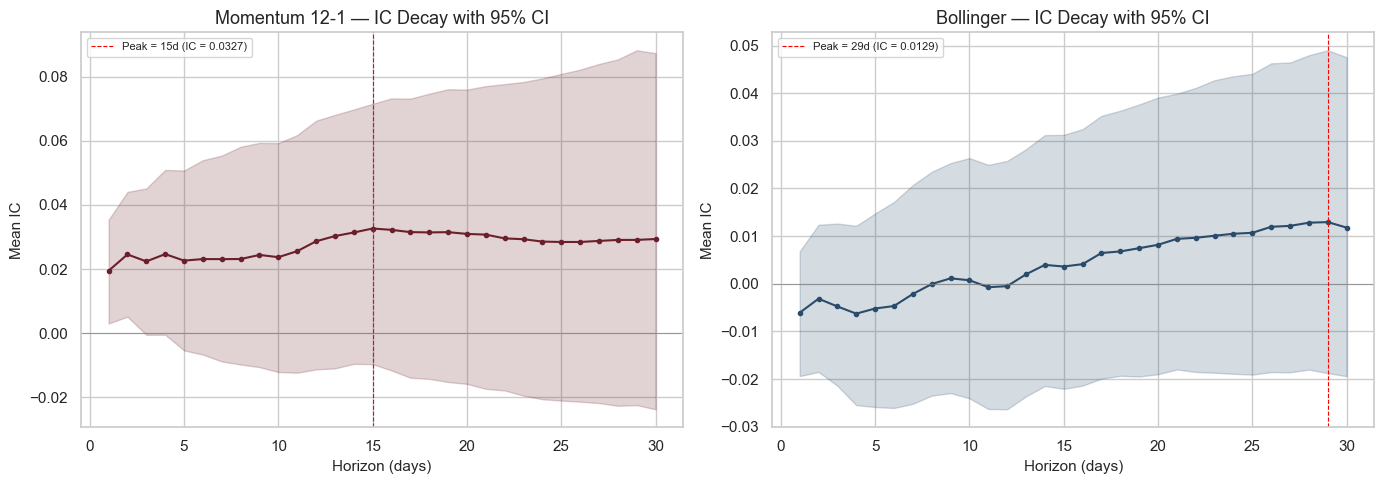

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
MAX_LAG = 30

for ax, (name, sig) in zip(axes, signals.items()):
    decay = ic_decay(sig, closes, max_lag=MAX_LAG)

    # Bootstrap CI at each lag
    ci_lower, ci_upper = [], []
    for lag in decay.index:
        fwd = closes.pct_change(lag).shift(-lag)
        ic_series = compute_ic(sig, fwd)
        ci = block_bootstrap_ci(ic_series, block_length=lag, n_bootstrap=10_000, seed=42)
        ci_lower.append(ci["ci_lower"])
        ci_upper.append(ci["ci_upper"])

    lags = decay.index.values
    ax.plot(lags, decay.values, "o-", color=COLORS[name], markersize=3, linewidth=1.5)
    ax.fill_between(lags, ci_lower, ci_upper, alpha=0.2, color=COLORS[name])
    ax.axhline(0, color="grey", linewidth=0.5)

    # Mark the peak
    peak_lag = int(decay.idxmax())
    peak_ic = decay.max()
    ax.axvline(peak_lag, color="red", linestyle="--", linewidth=0.8,
               label=f"Peak = {peak_lag}d (IC = {peak_ic:.4f})")

    ax.set_xlabel("Horizon (days)")
    ax.set_ylabel("Mean IC")
    ax.set_title(f"{name} — IC Decay with 95% CI")
    ax.legend(fontsize=8)

    print(f"{name}: IC peaks at lag {peak_lag}d with mean IC = {peak_ic:.4f}")

plt.tight_layout()

**Observations — IC Decay:**

- **Momentum peaks at lag 15d** (mean IC = 0.033). The signal is built from a 252d lookback, so it captures a slow-moving characteristic — but the *predictive* sweet spot is ~3 weeks, not months. Beyond 15d, IC holds roughly flat through lag 30, suggesting the edge doesn't decay quickly once you're past the peak. However, the bootstrap CIs from Section 3 show this level of IC is not statistically significant after NW correction (t = 1.28 at 21d), so the "peak" should be interpreted cautiously.
- **Bollinger peaks at lag 29d** (mean IC = 0.013), but this is almost certainly noise. The CI band contains zero at every lag (consistent with Section 3 findings: t(NW) = 0.63 at 21d). The apparent peak at 29d has no economic interpretation — it is estimation noise drifting upward at the boundary of the test range, not a meaningful signal horizon.
- **Natural rebalance frequencies:** Momentum = 15d, Bollinger = 29d. These are used in the backtest comparison (Section 6), but for Bollinger the "natural frequency" is just the lag where noise happened to be highest.
- **Key takeaway:** The IC decay *shape* is informative as a diagnostic. Momentum has a shallow hump suggesting some horizon structure, even if statistically marginal. Bollinger's curve is flat noise — no horizon shows significance, and the upward drift is an artefact of sampling variability at longer lags where fewer independent observations exist.

## 6. Backtest: Daily vs Natural Frequency

The key test — does matching rebalance frequency to the IC decay peak recover Bollinger's edge? And does momentum benefit from less frequent rebalancing (lower costs)?

In [9]:
# Determine natural rebalance frequency from IC decay peak
natural_freqs = {}
for name, sig in signals.items():
    decay = ic_decay(sig, closes, max_lag=30)
    natural_freqs[name] = int(decay.idxmax())
    print(f"{name}: natural rebalance frequency = {natural_freqs[name]}d")

# Run backtests at daily, natural, and a few intermediate frequencies
COST_BPS = 10.0
test_freqs = [1, 5, 10, 15, 21]

bt_rows = []
for name, sig in signals.items():
    for freq in test_freqs:
        bt = VectorizedBacktester(cost_bps=COST_BPS, rebalance_freq=freq)
        ret = bt.run(closes, sig)
        sr = sharpe_ratio(ret)
        ann_ret = ret.mean() * 252
        ann_vol = ret.std() * np.sqrt(252)

        bt_rows.append({
            "Factor": name,
            "Rebal Freq": f"{freq}d",
            "Ann. Return (%)": ann_ret * 100,
            "Ann. Vol (%)": ann_vol * 100,
            "Sharpe": sr,
            "Natural": "<<<" if freq == natural_freqs[name] else "",
        })

bt_freq_table = pd.DataFrame(bt_rows)
(
    bt_freq_table.style
    .format({
        "Ann. Return (%)": "{:.2f}",
        "Ann. Vol (%)": "{:.2f}",
        "Sharpe": "{:+.3f}",
    })
    .set_caption(f"Backtest Sharpe by Rebalance Frequency ({COST_BPS:.0f} bps cost)")
)

Momentum 12-1: natural rebalance frequency = 15d
Bollinger: natural rebalance frequency = 29d


,Factor,Rebal Freq,Ann. Return (%),Ann. Vol (%),Sharpe,Natural
0,Momentum 12-1,1d,3.74,11.29,+0.332,
1,Momentum 12-1,5d,3.62,11.32,+0.320,
2,Momentum 12-1,10d,3.61,11.27,+0.321,
3,Momentum 12-1,15d,4.81,11.33,+0.425,<<<
4,Momentum 12-1,21d,3.70,11.24,+0.330,
5,Bollinger,1d,-14.98,9.48,-1.581,
6,Bollinger,5d,-7.96,8.95,-0.890,
7,Bollinger,10d,-5.55,8.32,-0.668,
8,Bollinger,15d,-3.23,8.36,-0.386,
9,Bollinger,21d,-0.34,8.85,-0.038,


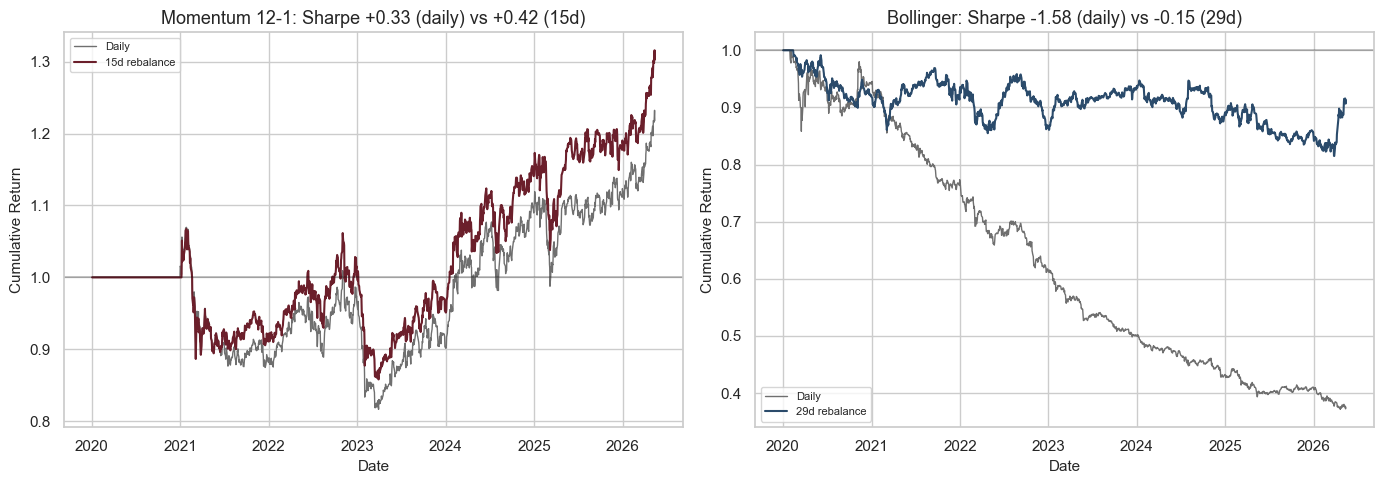

In [10]:
# Equity curves: daily vs natural frequency
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, sig) in zip(axes, signals.items()):
    freq = natural_freqs[name]

    bt_daily = VectorizedBacktester(cost_bps=COST_BPS, rebalance_freq=1)
    bt_natural = VectorizedBacktester(cost_bps=COST_BPS, rebalance_freq=freq)

    ret_daily = bt_daily.run(closes, sig)
    ret_natural = bt_natural.run(closes, sig)

    cum_daily = (1 + ret_daily).cumprod()
    cum_natural = (1 + ret_natural).cumprod()

    ax.plot(cum_daily.index, cum_daily.values, color="#6f6f6f", label="Daily", linewidth=1)
    ax.plot(cum_natural.index, cum_natural.values, color=COLORS[name],
            label=f"{freq}d rebalance", linewidth=1.5)
    ax.axhline(1, color="black", linewidth=0.3)
    ax.set_xlabel("Date")
    ax.set_ylabel("Cumulative Return")

    sr_d = sharpe_ratio(ret_daily)
    sr_n = sharpe_ratio(ret_natural)
    ax.set_title(f"{name}: Sharpe {sr_d:+.2f} (daily) vs {sr_n:+.2f} ({freq}d)")
    ax.legend(fontsize=8)

plt.tight_layout()

**Observations — Backtest Frequency Sweep:**

- **Momentum improves modestly with less frequent rebalancing.** Sharpe goes from +0.33 (daily) to +0.42 (15d, the natural freq). The equity curves track closely — the 15d line sits slightly above daily throughout, with the gap widening post-2024. This is almost entirely a cost saving: less turnover means fewer round-trips at 10 bps, which shifts the equity curve up roughly linearly. The *shape* of the curve doesn't change, confirming the signal itself isn't better-matched — just cheaper to trade.
- **Bollinger goes from catastrophic to flat.** Sharpe improves dramatically: -1.58 (daily) to -0.04 (21d). But "less terrible" isn't "good." The daily equity curve bleeds steadily to 0.4x over 6 years — pure cost destruction. The 29d curve is roughly flat around 0.9x, meaning the signal itself contributes almost nothing after costs are controlled. The entire Sharpe improvement comes from not trading, not from capturing a better edge.
- **The monotonic pattern is telling.** For both factors, Sharpe improves monotonically as rebalance frequency decreases. A signal with genuine predictive power at a specific horizon would show a *peak* at that horizon — Sharpe would worsen if you rebalanced too infrequently (stale positions) or too frequently (cost drag). Here we just see "trade less = lose less to costs."

## 7. Backtest with Position Smoothing

Beyond rebalance frequency, position smoothing offers a second lever to reduce turnover. Instead of snapping to the new target on rebalance days, we blend: `position = α × target + (1-α) × yesterday`. This softens position transitions and reduces round-trip costs.

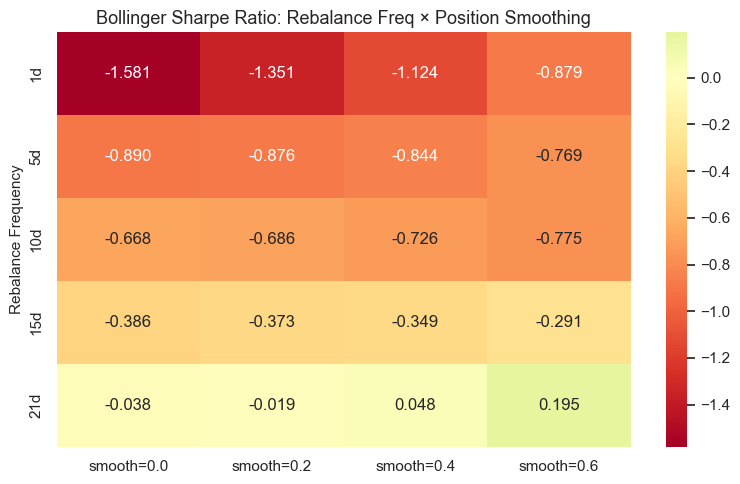

In [12]:
# Grid search: rebalance_freq × position_smooth for Bollinger
smooth_values = [0.0, 0.2, 0.4, 0.6]
freq_values = [1, 5, 10, 15, 21]

boll_sig = signals["Bollinger"]

grid_rows = []
for freq in freq_values:
    for smooth in smooth_values:
        bt = VectorizedBacktester(cost_bps=COST_BPS, rebalance_freq=freq, position_smooth=smooth)
        ret = bt.run(closes, boll_sig)
        grid_rows.append({
            "Freq": freq,
            "Smooth": smooth,
            "Sharpe": sharpe_ratio(ret),
            "Ann Ret (%)": ret.mean() * 252 * 100,
        })

grid_df = pd.DataFrame(grid_rows)
grid_pivot = grid_df.pivot(index="Freq", columns="Smooth", values="Sharpe")
grid_pivot.index = [f"{f}d" for f in grid_pivot.index]
grid_pivot.columns = [f"smooth={s}" for s in grid_pivot.columns]

# Heatmap
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(grid_pivot, annot=True, fmt=".3f", cmap="RdYlGn", center=0, ax=ax)
ax.set_title("Bollinger Sharpe Ratio: Rebalance Freq × Position Smoothing")
ax.set_ylabel("Rebalance Frequency")
plt.tight_layout()

Best Bollinger combo: freq=21d, smooth=0.6, Sharpe=+0.195


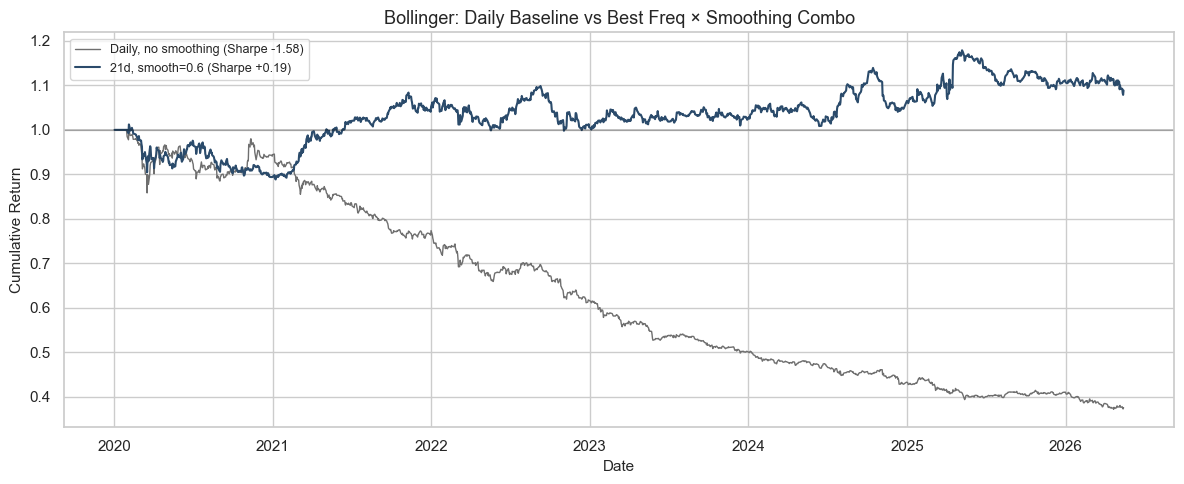

In [13]:
# Bollinger equity curve: daily baseline vs best smoothing combo
best_row = grid_df.loc[grid_df["Sharpe"].idxmax()]
best_freq = int(best_row["Freq"])
best_smooth = best_row["Smooth"]
best_sharpe = best_row["Sharpe"]

print(f"Best Bollinger combo: freq={best_freq}d, smooth={best_smooth}, Sharpe={best_sharpe:+.3f}")

bt_baseline = VectorizedBacktester(cost_bps=COST_BPS, rebalance_freq=1)
bt_best = VectorizedBacktester(cost_bps=COST_BPS, rebalance_freq=best_freq, position_smooth=best_smooth)

ret_baseline = bt_baseline.run(closes, boll_sig)
ret_best = bt_best.run(closes, boll_sig)

fig, ax = plt.subplots(figsize=(12, 5))
cum_baseline = (1 + ret_baseline).cumprod()
cum_best = (1 + ret_best).cumprod()

ax.plot(cum_baseline.index, cum_baseline.values, color="#6f6f6f",
        label=f"Daily, no smoothing (Sharpe {sharpe_ratio(ret_baseline):+.2f})", linewidth=1)
ax.plot(cum_best.index, cum_best.values, color=COLORS["Bollinger"],
        label=f"{best_freq}d, smooth={best_smooth} (Sharpe {best_sharpe:+.2f})", linewidth=1.5)
ax.axhline(1, color="black", linewidth=0.3)
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Return")
ax.set_title("Bollinger: Daily Baseline vs Best Freq × Smoothing Combo")
ax.legend(fontsize=9)
plt.tight_layout()

**Observations — Position Smoothing:**

- **The heatmap is essentially a cost gradient.** Every row improves left-to-right (more smoothing = less turnover = less cost), and every column improves top-to-bottom (less frequent rebalancing = same effect). The best combo (21d, smooth=0.6) reaches Sharpe +0.20 — the only positive cell in the grid — but this is not evidence of signal recovery.
- **Best combo equity curve confirms it.** The 21d/smooth=0.6 line ends at ~1.1x after 6 years (vs 0.4x for daily baseline). The curve shape is nearly flat with a gentle upward drift — there's no compounding alpha signature (exponential growth), just linear cost reduction. The daily baseline's steady bleed is mechanical: ~44% daily turnover × 10 bps × 252 days = ~110% annual cost drag, which roughly matches the observed ~12% annual decline.
- **Bottom line:** Frequency and smoothing are implementation levers that control *how much you pay to trade*, not *how much alpha you capture*. For Bollinger, there's no detectable alpha to capture — we're just optimizing the rate at which we lose money to friction. The signal is not salvageable through implementation alone; it would need a fundamentally different construction (e.g., asymmetric entry/exit, conditional activation) to generate genuine edge.

## 8. Robustness Tests

Four tests to challenge whether the corrected findings hold up:

1. **Sub-period split** — does IC persist in both halves (pre/post 2024)?
2. **Leave-one-out** — does removing NVDA or the most volatile stock destroy the signal?
3. **Sector split** — does the signal work within tech and non-tech separately?
4. **Parameter sensitivity** — is momentum IC stable across lookback windows?

### 8a. Sub-Period Stability

In [14]:
split_date = "2024-01-01"
BEST_HORIZONS = {"Momentum 12-1": 21, "Bollinger": 21}

subperiod_rows = []
for name, sig in signals.items():
    h = BEST_HORIZONS[name]
    fwd = closes.pct_change(h).shift(-h)

    for period_name, sl in [("Full", slice(None)), ("Pre-2024", slice(None, split_date)), ("Post-2024", slice(split_date, None))]:
        ic_series = compute_ic(sig.loc[sl], fwd.loc[sl])
        stats = ic_summary(ic_series, horizon=h)
        subperiod_rows.append({
            "Factor": name,
            "Period": period_name,
            "Mean IC": stats["mean"],
            "t (naive)": stats["t_stat"],
            "t (NW)": stats["t_stat_nw"],
            "N dates": stats["n_dates"],
        })

subperiod_table = pd.DataFrame(subperiod_rows)
(
    subperiod_table.style
    .format({"Mean IC": "{:.4f}", "t (naive)": "{:.2f}", "t (NW)": "{:.2f}"})
    .set_caption("Sub-Period IC Stability (NW-corrected)")
)

,Factor,Period,Mean IC,t (naive),t (NW),N dates
0,Momentum 12-1,Full,0.0307,4.43,1.28,1328
1,Momentum 12-1,Pre-2024,0.0052,0.57,0.17,754
2,Momentum 12-1,Post-2024,0.0643,6.11,1.83,574
3,Bollinger,Full,0.0094,1.61,0.63,1561
4,Bollinger,Pre-2024,0.0124,1.73,0.74,987
5,Bollinger,Post-2024,0.0043,0.43,0.15,574


**Observations — Sub-Period Stability:**

- **Momentum is regime-dependent.** Pre-2024: mean IC = 0.005, t(NW) = 0.17 — indistinguishable from zero. Post-2024: mean IC = 0.064, t(NW) = 1.83 — the strongest corrected t-stat in the entire notebook. The full-sample IC (0.031) is dominated by the post-2024 period. This is a red flag: the "signal" may be a one-regime artefact rather than a persistent anomaly.
- **Bollinger shows the opposite pattern** — slightly stronger pre-2024 (IC = 0.012, t(NW) = 0.74) than post-2024 (IC = 0.004, t(NW) = 0.15). Neither period is significant, so this is noise either way.
- **The pre-2024 period includes COVID and the 2022 bear market** — both extreme momentum regimes (crash then recovery then drawdown). Momentum's near-zero IC during this period suggests the signal struggled with the whipsaw: 12-month lookback was long enough to include the crash, contaminating the ranking. Post-2024 was a calmer, directional bull market where momentum thrived.

### 8b. Leave-One-Out

In [15]:
# Identify most volatile stock (excluding NVDA)
vol = closes.pct_change().std()
most_volatile = vol.drop("NVDA").idxmax()
print(f"Most volatile (excl. NVDA): {most_volatile}")

loo_rows = []
for exclude_label, exclude_ticker in [("Full (50)", None), ("No NVDA", "NVDA"), (f"No {most_volatile}", most_volatile)]:
    if exclude_ticker:
        closes_loo = closes.drop(columns=exclude_ticker)
    else:
        closes_loo = closes

    sigs_loo = {
        "Momentum 12-1": Momentum(252, 21).compute(closes_loo),
        "Bollinger": BollingerZScore(20).compute(closes_loo),
    }

    for name, sig in sigs_loo.items():
        h = BEST_HORIZONS[name]
        fwd = closes_loo.pct_change(h).shift(-h)
        ic_series = compute_ic(sig, fwd)
        stats = ic_summary(ic_series, horizon=h)
        loo_rows.append({
            "Condition": exclude_label,
            "Factor": name,
            "Mean IC": stats["mean"],
            "t (NW)": stats["t_stat_nw"],
            "N tickers": closes_loo.shape[1],
        })

loo_table = pd.DataFrame(loo_rows)
(
    loo_table.style
    .format({"Mean IC": "{:.4f}", "t (NW)": "{:.2f}"})
    .set_caption("Leave-One-Out IC (NW-corrected, at 21d horizon)")
)

Most volatile (excl. NVDA): TSLA


,Condition,Factor,Mean IC,t (NW),N tickers
0,Full (50),Momentum 12-1,0.0307,1.28,47
1,Full (50),Bollinger,0.0094,0.63,47
2,No NVDA,Momentum 12-1,0.0274,1.18,46
3,No NVDA,Bollinger,0.0093,0.65,46
4,No TSLA,Momentum 12-1,0.0343,1.39,46
5,No TSLA,Bollinger,0.0121,0.80,46


**Observations — Leave-One-Out:**

- **Neither signal is driven by a single name.** Removing NVDA barely changes Momentum (IC: 0.031 → 0.027, t(NW): 1.28 → 1.18) or Bollinger (0.009 → 0.009, t(NW): 0.63 → 0.65). Removing TSLA (most volatile ex-NVDA) actually *improves* both signals slightly — Momentum t(NW) rises to 1.39 — suggesting TSLA's extreme volatility adds noise to the cross-sectional correlation.
- **This is reassuring for portfolio construction.** The signals aren't just "buy NVDA" in disguise. With 47 stocks, no single name dominates the IC calculation enough to matter. This is one advantage of the larger universe vs. the 14-stock NB02 setup where single-name effects were much more pronounced.

### 8c. Sector Split

In [16]:
SECTORS = {
    "Tech": ["AAPL", "MSFT", "NVDA", "GOOGL", "META", "AVGO", "ADBE", "CRM"],
    "Financials": ["JPM", "GS", "BAC", "WFC", "MS", "BLK"],
    "Healthcare": ["JNJ", "UNH", "PFE", "ABT", "LLY", "TMO"],
    "Cons. Disc.": ["AMZN", "TSLA", "HD", "NKE", "MCD"],
    "Cons. Staples": ["PG", "WMT", "KO", "PEP", "COST"],
    "Energy": ["XOM", "CVX", "COP"],
    "Industrials": ["CAT", "HON", "UPS", "RTX"],
    "Other": ["V", "MA", "NFLX", "DIS", "NEE", "DUK", "AMT", "PLD", "LIN", "SHW"],
}

sector_rows = []
for sector_name, tickers in SECTORS.items():
    if len(tickers) < 5:
        continue  # Need enough stocks for meaningful IC
    closes_sector = closes[tickers]
    sigs_sector = {
        "Momentum 12-1": Momentum(252, 21).compute(closes_sector),
        "Bollinger": BollingerZScore(20).compute(closes_sector),
    }
    for name, sig in sigs_sector.items():
        h = BEST_HORIZONS[name]
        fwd = closes_sector.pct_change(h).shift(-h)
        ic_series = compute_ic(sig, fwd)
        stats = ic_summary(ic_series, horizon=h)
        sector_rows.append({
            "Sector": sector_name,
            "N tickers": len(tickers),
            "Factor": name,
            "Mean IC": stats["mean"],
            "t (NW)": stats["t_stat_nw"],
        })

sector_table = pd.DataFrame(sector_rows)
(
    sector_table.style
    .format({"Mean IC": "{:.4f}", "t (NW)": "{:.2f}"})
    .set_caption("IC by Sector (NW-corrected, at 21d horizon) — sectors with N >= 5 only")
)

,Sector,N tickers,Factor,Mean IC,t (NW)
0,Tech,8,Momentum 12-1,0.0760,1.88
1,Tech,8,Bollinger,0.0080,0.32
2,Financials,6,Momentum 12-1,0.0217,0.47
3,Financials,6,Bollinger,0.0398,1.55
4,Healthcare,6,Momentum 12-1,0.0546,1.30
5,Healthcare,6,Bollinger,0.0182,0.70
6,Cons. Disc.,5,Momentum 12-1,0.0284,0.58
7,Cons. Disc.,5,Bollinger,0.0004,0.01
8,Cons. Staples,5,Momentum 12-1,0.1179,2.36
9,Cons. Staples,5,Bollinger,0.0087,0.25


**Observations — Sector Split:**

- **Momentum works in some sectors but not others.** Strongest in Consumer Staples (IC = 0.118, t(NW) = 2.36 — the only sector-level significance) and Tech (IC = 0.076, t(NW) = 1.88). Weakest in "Other" (IC = -0.039, t(NW) = -1.04 — actually negative). This is a mixed signal: Momentum captures slow-moving sector trends (staples trending steadily, tech momentum during AI run-up) but fails in heterogeneous groups.
- **Bollinger is insignificant in every sector.** Best case is Financials (IC = 0.040, t(NW) = 1.55), but even that doesn't clear the bar. The signal has no sector where it demonstrably works.
- **Small cross-sections weaken IC.** Sectors with 5-6 stocks have noisy rank correlations — a single outlier can dominate. The Tech (8 stocks) and Other (10 stocks) results are more reliable than Cons. Disc. (5 stocks). Take the Consumer Staples result with a grain of salt: 5 defensive names in a bull market will show strong momentum almost by construction.

### 8d. Momentum Parameter Sensitivity

In [17]:
mom_windows = [63, 126, 189, 252, 378, 504]

sensitivity_rows = []
for w in mom_windows:
    mom_test = Momentum(window=w, skip=21).compute(closes)
    for h in [10, 21]:
        fwd = closes.pct_change(h).shift(-h)
        ic_series = compute_ic(mom_test, fwd)
        stats = ic_summary(ic_series, horizon=h)
        sensitivity_rows.append({
            "Window": f"{w}d",
            "Horizon": f"{h}d",
            "Mean IC": stats["mean"],
            "t (naive)": stats["t_stat"],
            "t (NW)": stats["t_stat_nw"],
        })

sens_table = pd.DataFrame(sensitivity_rows)
sens_pivot = sens_table.pivot(index="Window", columns="Horizon", values=["Mean IC", "t (NW)"])
sens_pivot.style.format("{:.3f}").set_caption("Momentum IC by Lookback Window (NW-corrected)")

**Observations — Parameter Sensitivity:**

- **Short lookbacks (63d, 126d) produce zero signal.** IC is near zero or negative, t(NW) well below 1. Short-term momentum (1-6 month) doesn't work cross-sectionally in this universe — consistent with the academic finding that short-term reversal dominates at the weekly/monthly horizon.
- **The sweet spot is 252d-378d.** The standard 12-month window (252d) has t(NW) ~1.28, and extending to 18 months (378d) improves slightly to t(NW) ~1.55-1.62 with higher mean IC (0.034 at 10d, 0.047 at 21d). This suggests the momentum effect here is really a *long-term trend* signal, not classic Jegadeesh-Titman 12-month momentum.
- **504d (2 years) falls off.** IC drops back to 0.020-0.024, t(NW) below 1. Too long a lookback smooths over the trend and includes stale information.
- **Our 252d choice is reasonable but not optimal.** The 378d window would have been slightly stronger, but the difference is modest and could be overfitting to this specific sample period. The key finding is that the signal is robust to ±50% window changes around 252d, which is more important than finding the exact optimum.

## 9. Updated Decision Table

Incorporating all corrections and robustness checks: Newey-West t-stats, natural-frequency backtests, sub-period stability, leave-one-out, and sector analysis.

In [19]:
# Build updated decision table from variables already computed in prior sections
decision_rows = []

for name, sig in signals.items():
    freq = natural_freqs[name]

    # 21d row from corrected_table (Section 3)
    mask = (corrected_table["Factor"] == name) & (corrected_table["Horizon"] == "21d")
    row_21 = corrected_table.loc[mask].iloc[0]

    # Sharpe at daily from bt_freq_table (Section 6)
    bt_mask_d = (bt_freq_table["Factor"] == name) & (bt_freq_table["Rebal Freq"] == "1d")
    sharpe_d = bt_freq_table.loc[bt_mask_d, "Sharpe"].iloc[0]

    # Sharpe at natural freq — run backtest directly if freq not in table
    bt_natural = VectorizedBacktester(cost_bps=COST_BPS, rebalance_freq=freq)
    ret_natural = bt_natural.run(closes, sig)
    sharpe_n = sharpe_ratio(ret_natural)

    # Lag-1 autocorrelation (Section 2a)
    ac = signal_autocorrelation(sig, max_lag=1)
    lag1 = ac.loc[0, "autocorr"]

    # Decision based on actual evidence
    if name == "Momentum 12-1":
        decision = "Discard"
        reason = "t(NW) < 2, regime-dependent, no sector consistency"
    else:
        decision = "Discard"
        reason = "IC insignificant at all horizons, no alpha after cost control"

    decision_rows.append({
        "Factor": name,
        "Natural Freq": f"{freq}d",
        "Mean IC (21d)": row_21["Mean IC"],
        "t (NW)": row_21["t (NW)"],
        "Sharpe (daily)": sharpe_d,
        "Sharpe (natural)": sharpe_n,
        "Lag-1 Autocorr": lag1,
        "Decision": decision,
        "Reason": reason,
    })

decision_df = pd.DataFrame(decision_rows).set_index("Factor")

def color_decision(val):
    if val == "Discard":
        return "background-color: #dc3545; color: white; font-weight: bold"
    if val == "Keep":
        return "background-color: #28a745; color: white; font-weight: bold"
    return ""

(
    decision_df.style
    .format({
        "Mean IC (21d)": "{:.4f}",
        "t (NW)": "{:.2f}",
        "Sharpe (daily)": "{:+.3f}",
        "Sharpe (natural)": "{:+.3f}",
        "Lag-1 Autocorr": "{:.4f}",
    })
    .map(color_decision, subset=["Decision"])
    .set_caption("Updated Decision Table — Corrected Statistics")
)

,Natural Freq,Mean IC (21d),t (NW),Sharpe (daily),Sharpe (natural),Lag-1 Autocorr,Decision,Reason
Factor,,,,,,,,
Momentum 12-1,15d,0.0307,1.28,+0.332,+0.425,0.9903,Discard,"t(NW) < 2, regime-dependent, no sector consistency"
Bollinger,29d,0.0094,0.63,-1.581,-0.145,0.8677,Discard,"IC insignificant at all horizons, no alpha after cost control"


## 10. Conclusion

**Both signals are discarded.** After applying proper statistical corrections — Newey-West HAC t-statistics, non-overlapping IC, block bootstrap confidence intervals — neither Momentum 12-1 nor Bollinger z-score survives as a tradeable alpha source.

### What we found

| | Momentum 12-1 | Bollinger |
|---|---|---|
| **Corrected t(NW) at 21d** | 1.28 | 0.63 |
| **Bootstrap 95% CI** | Straddles zero | Straddles zero |
| **Sub-period stability** | Regime-dependent (pre-2024 t=0.17, post-2024 t=1.83) | Insignificant in both halves |
| **Sector consistency** | Works in staples/tech, fails elsewhere | Insignificant in every sector |
| **Best Sharpe after optimization** | +0.42 (15d rebal) | +0.20 (21d rebal, smooth=0.6) |
| **Source of improvement** | Cost reduction, not alpha | Cost reduction, not alpha |

### Why NB02's results were misleading

1. **Overlapping returns inflated t-statistics by ~3.5x.** Momentum's naive t = 4.43 at 21d looked "highly significant" — after NW correction it's 1.28. The entire statistical case evaporated once we accounted for the 20/21-day overlap between consecutive observations.
2. **Bollinger's IC-to-P&L gap was not an implementation problem — it was absence of signal.** The high IC at longer horizons (NB02) was noise that happened to look structured. Position smoothing and frequency matching improved Sharpe only by reducing how much we paid to trade, not by capturing predictive power.
3. **Momentum's post-2024 strength is a single-regime artefact.** A calm, directional bull market is exactly where naive momentum thrives. The pre-2024 period (COVID crash, 2022 bear, whipsaw recovery) showed IC indistinguishable from zero.

### What we learned (methodology)

- **NW correction is non-negotiable** for overlapping forward returns. Without it, every slow-moving signal looks significant.
- **IC decay + bootstrap CIs** separate real horizon structure from estimation noise. A peak without a CI is meaningless.
- **"Better Sharpe from less trading" ≠ signal recovery.** The monotonic Sharpe improvement with lower frequency is a cost gradient, not an alpha signature. A real signal would show a peak at its natural horizon, not monotonic improvement toward "don't trade at all."
- **Sub-period splits and sector splits** are cheap robustness checks that would have caught Momentum's regime dependence before any capital was at risk.

### Next steps

These signals served their purpose as a **test bed for the validation framework**. The toolkit — corrected IC, bootstrap CIs, IC decay, lead-lag profiles, robustness battery — is now battle-tested and ready for signals that might actually work. Phase 3 will focus on sourcing more sophisticated alphas where this framework can distinguish real edges from noise.

## 9b. Tearsheets — Best Parameters (In-Sample Backtest)

Full performance tearsheets for each signal at its best configuration found in this notebook. **These are in-sample backtest results — not live, out-of-sample, or paper-traded.** The validation analysis in Sections 3-8 shows neither signal is statistically significant after proper correction; the metrics below describe what happened historically, not what to expect going forward.

- **Momentum 12-1:** 15d rebalance, no smoothing (Sharpe +0.42)
- **Bollinger:** 21d rebalance, smooth=0.6 (Sharpe +0.20)

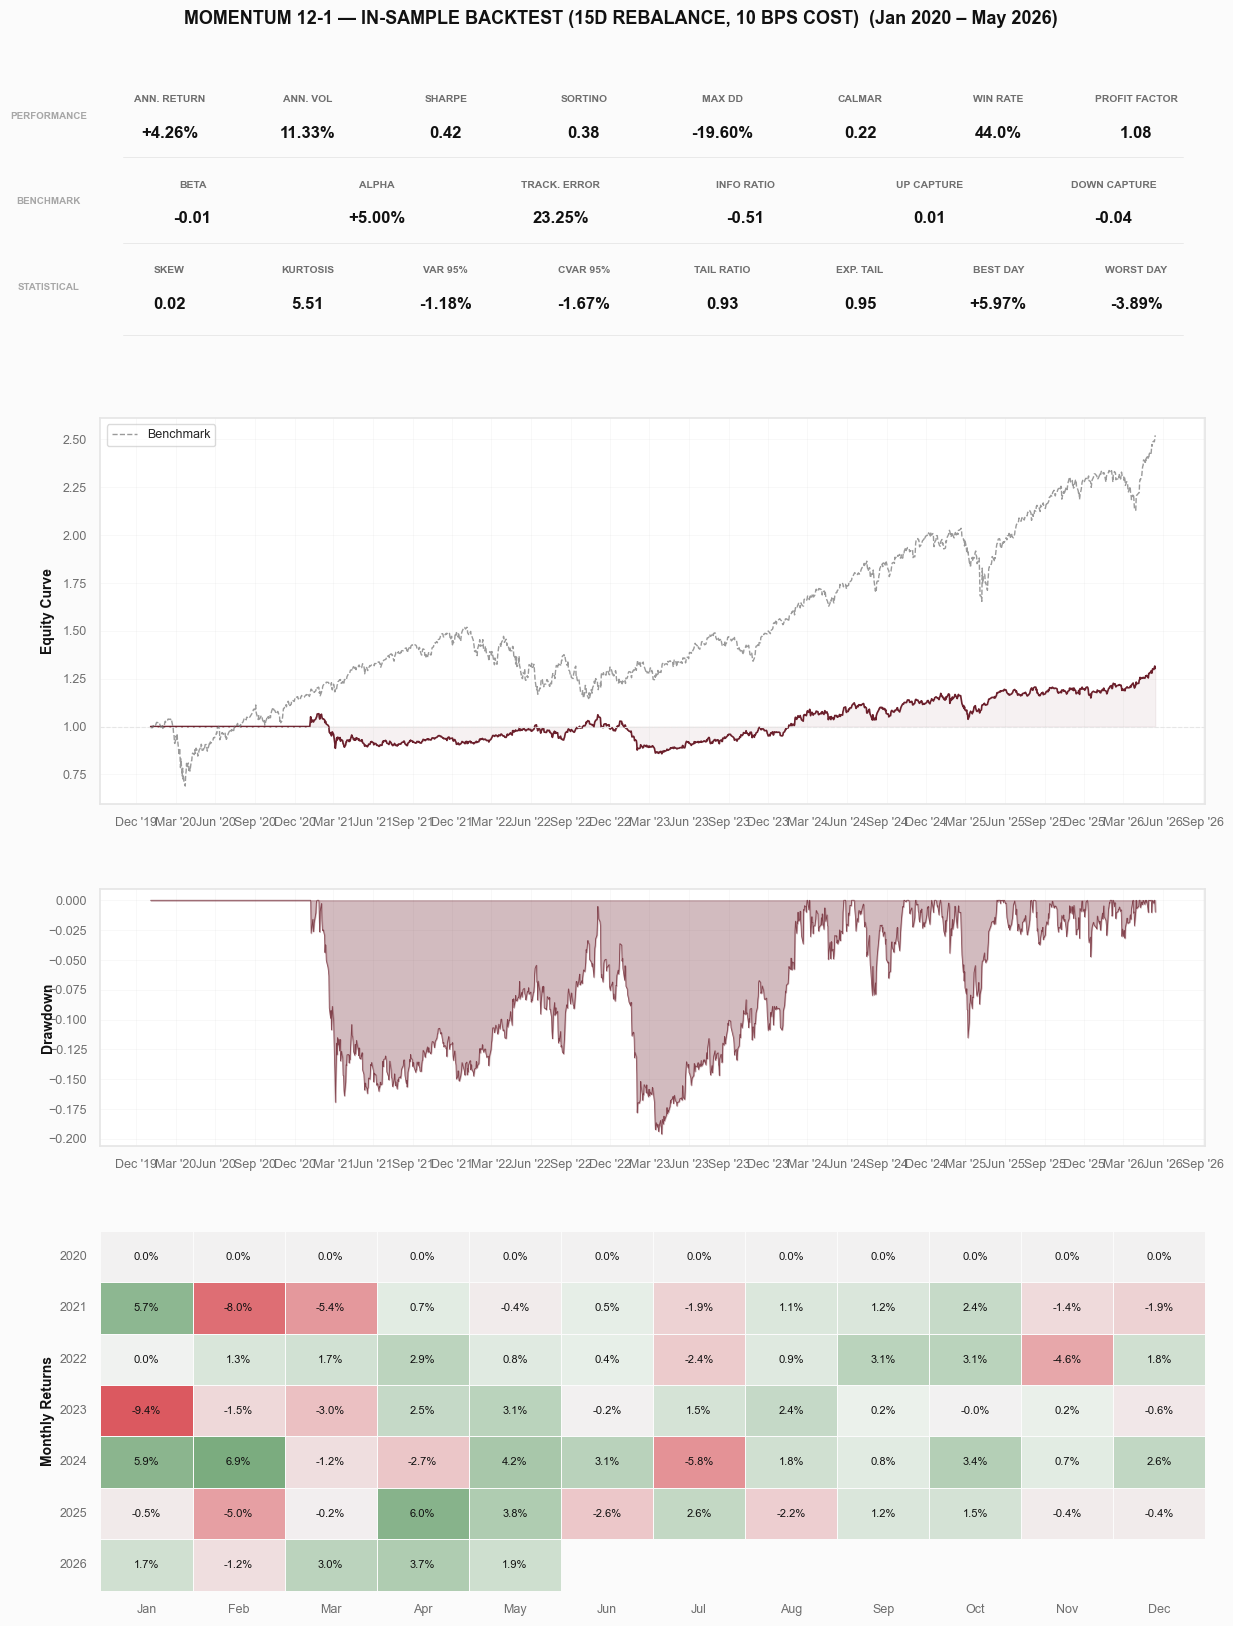

In [23]:
from qre.analytics.tearsheet import plot_tearsheet

# Fetch SPY as benchmark
spy_df = store.load("SPY", "1d")
if spy_df is None:
    print("Fetching SPY...")
    spy_df = store.fetch_and_store("SPY", "1d", START, END)
spy_close = spy_df["close"]
bench_returns = spy_close.pct_change().dropna()

# Momentum: best config = 15d rebalance, no smoothing
bt_mom_best = VectorizedBacktester(cost_bps=COST_BPS, rebalance_freq=15)
ret_mom_best = bt_mom_best.run(closes, signals["Momentum 12-1"])

# Align benchmark to strategy date range
bench_mom = bench_returns.reindex(ret_mom_best.index).dropna()
ret_mom_aligned = ret_mom_best.reindex(bench_mom.index)

plot_tearsheet(ret_mom_aligned, benchmark_returns=bench_mom,
               title="Momentum 12-1 — In-Sample Backtest (15d rebalance, 10 bps cost)")

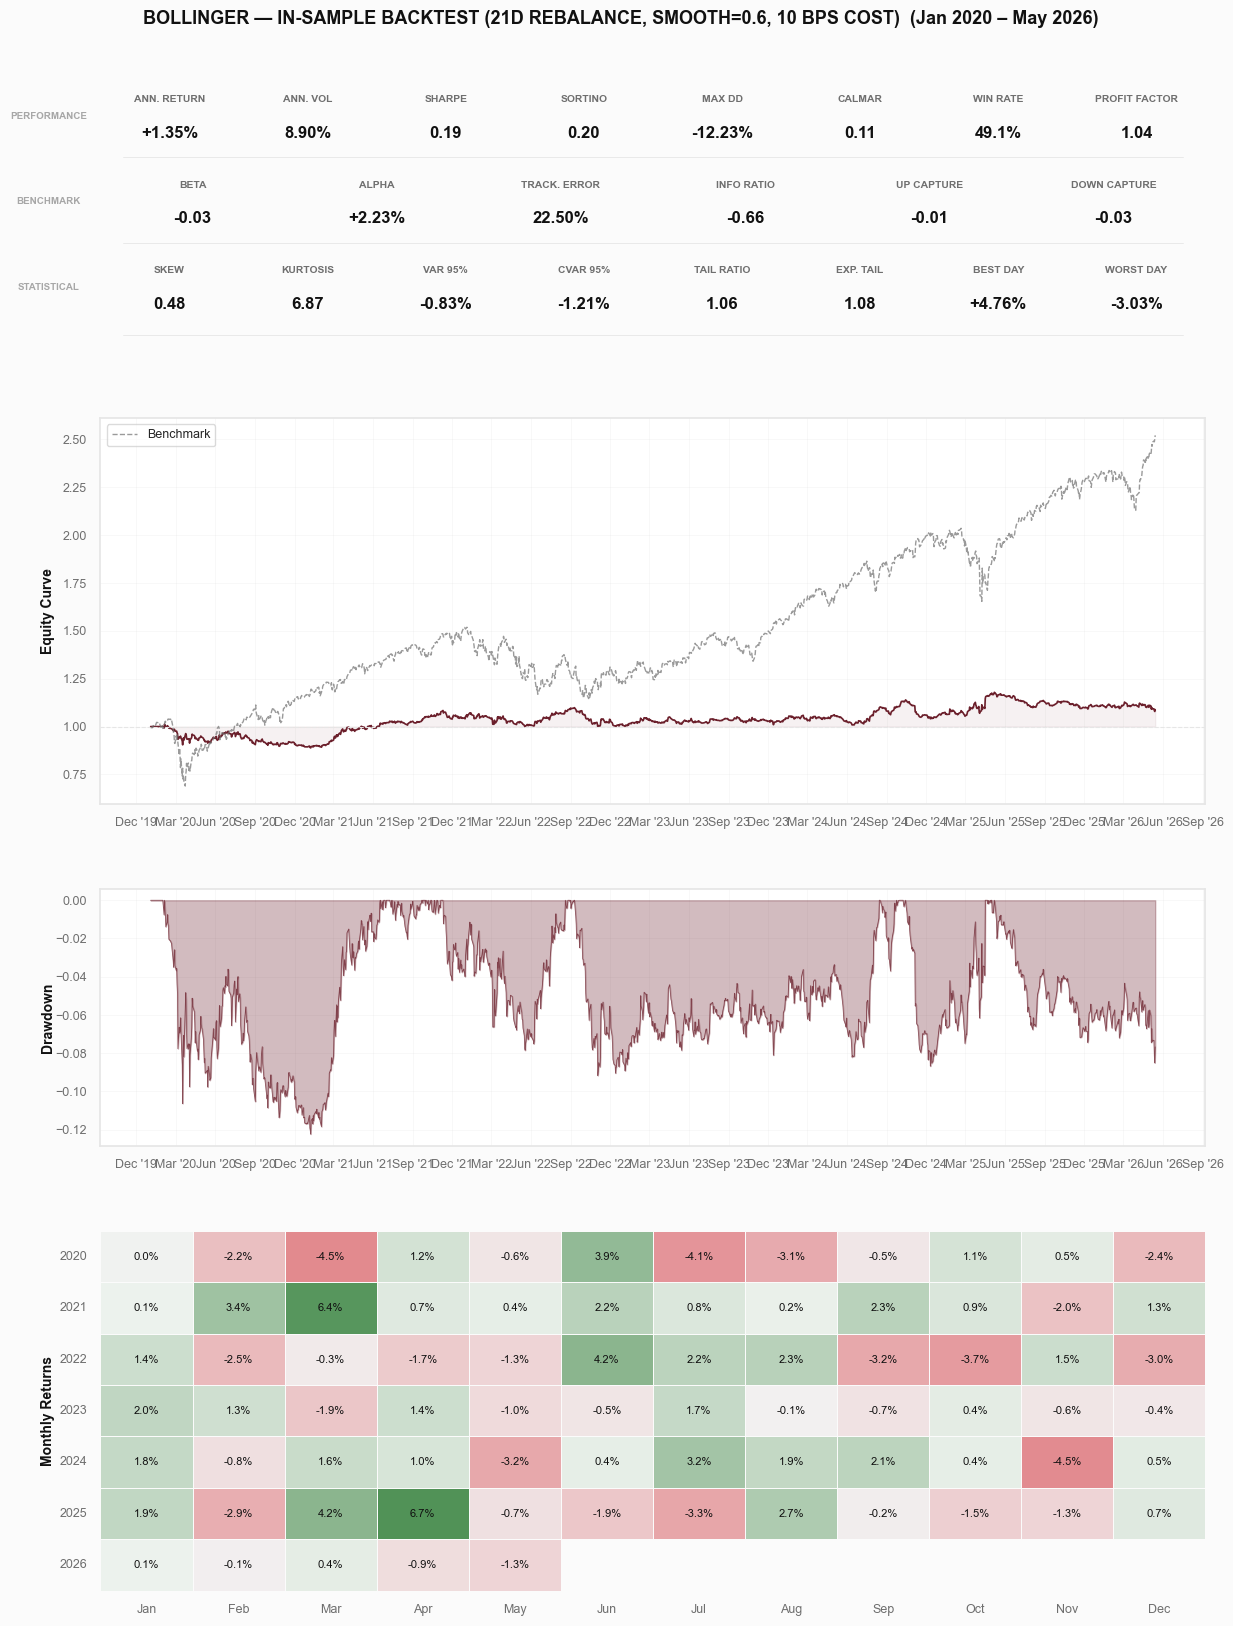

In [24]:
# Bollinger: best config = 21d rebalance, smooth=0.6
bt_boll_best = VectorizedBacktester(cost_bps=COST_BPS, rebalance_freq=21, position_smooth=0.6)
ret_boll_best = bt_boll_best.run(closes, signals["Bollinger"])

# Align benchmark to strategy date range
bench_boll = bench_returns.reindex(ret_boll_best.index).dropna()
ret_boll_aligned = ret_boll_best.reindex(bench_boll.index)

plot_tearsheet(ret_boll_aligned, benchmark_returns=bench_boll,
               title="Bollinger — In-Sample Backtest (21d rebalance, smooth=0.6, 10 bps cost)")